# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

# 2. Acquire and load your primary dataset
api_url = (
    "https://api.worldbank.org/v2/country/all/"
    "indicator/NY.GDP.PCAP.CD"
    "?format=json&per_page=20000"
)

response = requests.get(api_url)

gdp_data = response.json()[1]

primary_df = pd.DataFrame(gdp_data)

primary_df.head()

Current working directory:
c:\Users\81809\OneDrive\ドキュメント\GitHub\datascience-publicpolicy-2026\notebooks\hw\hw_3

Files in current directory:
['shota emoto.ipynb']


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2025,NaN,,,1
1,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,1615.396356,,,1
2,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,1571.449189,,,1
3,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,1679.327622,,,1
4,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,1562.416175,,,1


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- Dataset Source: World Bank Open Data API (World Development Indicators).

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1. Inspect data structure using pandas methods

primary_df.info()
primary_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 17556 entries, 0 to 17555
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   indicator        17556 non-null  object 
 1   country          17556 non-null  object 
 2   countryiso3code  17556 non-null  str    
 3   date             17556 non-null  str    
 4   value            14561 non-null  float64
 5   unit             17556 non-null  str    
 6   obs_status       17556 non-null  str    
 7   decimal          17556 non-null  int64  
dtypes: float64(1), int64(1), object(2), str(4)
memory usage: 1.1+ MB


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2025,NaN,,,1
1,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,1615.396356,,,1
2,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,1571.449189,,,1
3,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,1679.327622,,,1
4,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,1562.416175,,,1


In [3]:
# 2. Rename columns and select a clean subset
primary_df = primary_df[[
    "countryiso3code",
    "country",
    "date",
    "value"
]]

column_mapping = {
    "countryiso3code": "country_code",
    "country": "country",
    "date": "year",
    "value": "gdp_per_capita"
}

primary_df = primary_df.rename(columns=column_mapping)

In [4]:
# 3. Filter row or column filters if necessary
primary_df["country"] = primary_df["country"].apply(lambda x: x["value"])

primary_df = primary_df.query("year == '2023'")

In [5]:
# 4. Handle missing values (NaNs) if necessary
primary_df = primary_df.dropna(subset=["country_code", "gdp_per_capita"])

primary_df.head()

,country_code,country,year,gdp_per_capita
2,AFE,Africa Eastern and Southern,2023,1571.449189
68,AFW,Africa Western and Central,2023,1841.855064
134,ARB,Arab World,2023,7513.899079
200,CSS,Caribbean small states,2023,17596.540425
266,CEB,Central Europe and the Baltics,2023,22690.373617


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [6]:
# 1. Load and clean the secondary dataset
life_expectancy_url = (
    "https://api.worldbank.org/v2/country/all/"
    "indicator/SP.DYN.LE00.IN"
    "?format=json&per_page=20000"
)

response = requests.get(life_expectancy_url)

secondary_df = pd.DataFrame(response.json()[1])

secondary_df = secondary_df[[
    "countryiso3code",
    "country",
    "date",
    "value"
]]

column_mapping = {
    "countryiso3code": "country_code",
    "country": "country",
    "date": "year",
    "value": "life_expectancy"
}

secondary_df = secondary_df.rename(columns=column_mapping)

secondary_df["country"] = secondary_df["country"].apply(lambda x: x["value"])

secondary_df = secondary_df.query("year == '2023'")

secondary_df = secondary_df.dropna(subset=["country_code", "life_expectancy"])

In [7]:
# 2. Merge your datasets on a common key
merged_df = primary_df.merge(
    secondary_df,
    on=["country_code", "country", "year"],
    how="inner"
)

print("Merged dataset shape:")
print(merged_df.shape)

merged_df.head()
print(merged_df.shape[0])

Merged dataset shape:
(251, 5)
251


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- Merge Key:
The two datasets were merged using country code, country name, and year. These variables uniquely identify each country's observation for the selected year (2023).

- Observations Retained:
After merging and removing missing values, 251 observations were retained for analysis.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [8]:
# Apply groupby aggregation or implement one of the backup grouping strategies
gdp_bins = [0, 5000, 20000, float("inf")]
gdp_labels = ["Low Income", "Middle Income", "High Income"]

merged_df["gdp_group"] = pd.cut(
    merged_df["gdp_per_capita"],
    bins=gdp_bins,
    labels=gdp_labels
)

grouped_df = merged_df.groupby("gdp_group")["life_expectancy"].agg(
    ["count", "mean", "median", "min", "max"]
)

print(grouped_df)

               count       mean     median     min     max
gdp_group                                                 
Low Income        95  67.018389  66.777000  54.462  77.817
Middle Income     80  74.031260  74.415500  62.109  81.167
High Income       76  80.584390  81.637171  70.180  86.372


- Interpretation: Countries with higher GDP per capita generally have higher average life expectancy. This suggests that economic development is associated with better health outcomes, although other factors such as healthcare systems and public policy may also play important roles.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

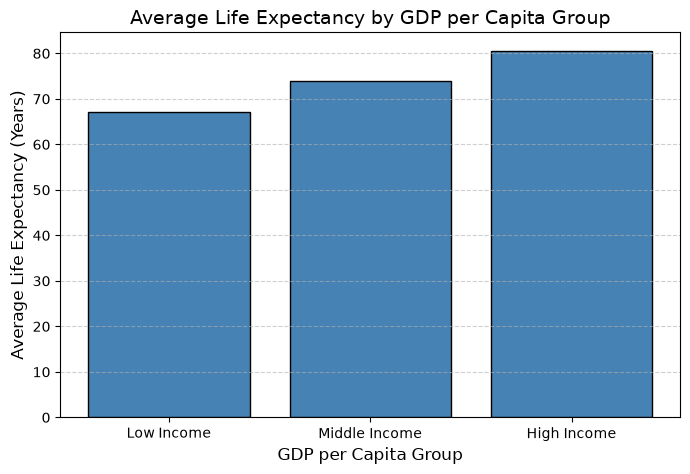

In [9]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
plt.figure(figsize=(8, 5))

plt.bar(
    grouped_df.index.astype(str),
    grouped_df["mean"],
    color="steelblue",
    edgecolor="black"
)

plt.title("Average Life Expectancy by GDP per Capita Group", fontsize=14)
plt.xlabel("GDP per Capita Group", fontsize=12)
plt.ylabel("Average Life Expectancy (Years)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

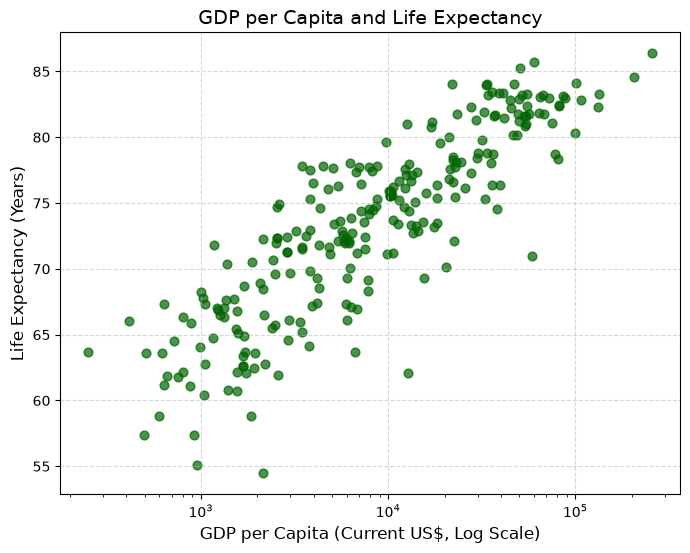

In [10]:
# Plot 2: Customized scatter plot of primary policy variables
plt.figure(figsize=(8, 6))

plt.scatter(
    merged_df["gdp_per_capita"],
    merged_df["life_expectancy"],
    color="darkgreen",
    alpha=0.7,
    s=40
)

plt.xscale("log")

plt.title("GDP per Capita and Life Expectancy", fontsize=14)
plt.xlabel("GDP per Capita (Current US$, Log Scale)", fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     723.5
Date:                Tue, 30 Jun 2026   Prob (F-statistic):           1.27e-75
Time:                        15:14:14   Log-Likelihood:                -671.90
No. Observations:                 251   AIC:                             1348.
Df Residuals:                     249   BIC:                             1355.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 35.6675      1

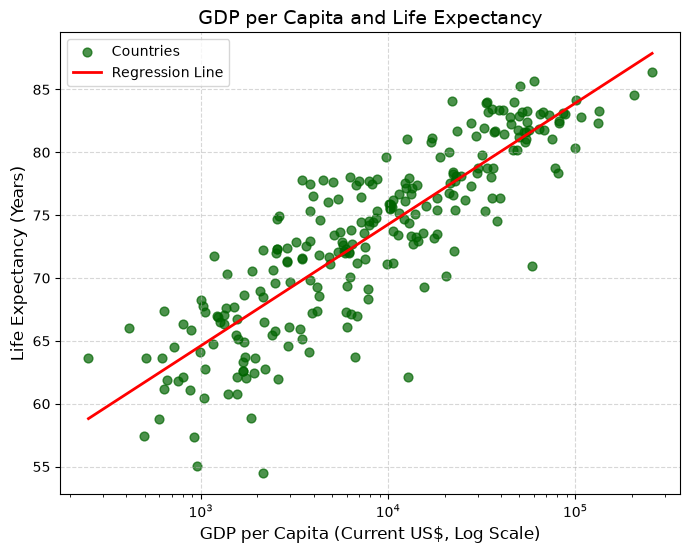

In [12]:
# Fit a simple linear regression and overlay the line of best fit

import numpy as np
import statsmodels.api as sm

# Create log-transformed GDP variable
merged_df["log_gdp_per_capita"] = np.log(merged_df["gdp_per_capita"])

# Fit the regression model
X = sm.add_constant(merged_df["log_gdp_per_capita"])
y = merged_df["life_expectancy"]

model = sm.OLS(y, X).fit()

# Print regression results
print(model.summary())

# Create values for a smooth regression line
gdp_range = np.linspace(
    merged_df["gdp_per_capita"].min(),
    merged_df["gdp_per_capita"].max(),
    200
)

X_line = sm.add_constant(np.log(gdp_range))
y_line = model.predict(X_line)

# Create the figure
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(
    merged_df["gdp_per_capita"],
    merged_df["life_expectancy"],
    color="darkgreen",
    alpha=0.7,
    s=40,
    label="Countries"
)

# Regression line
plt.plot(
    gdp_range,
    y_line,
    color="red",
    linewidth=2,
    label="Regression Line"
)

# Customize plot
plt.xscale("log")
plt.title("GDP per Capita and Life Expectancy", fontsize=14)
plt.xlabel("GDP per Capita (Current US$, Log Scale)", fontsize=12)
plt.ylabel("Life Expectancy (Years)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.show()

- Visualization Interpretation:
The bar chart shows that countries in higher GDP per capita groups tend to have higher average life expectancy. The scatter plot also suggests a positive relationship between GDP per capita and life expectancy, although the relationship becomes weaker among high-income countries.

- Regression Interpretation:
The regression results indicate a positive association between the logarithm of GDP per capita and life expectancy. The estimated slope coefficient suggests that countries with higher income levels generally experience longer life expectancy, although this analysis is exploratory and does not imply causality.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.